In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)


In [2]:
# only get DA in US
df_DA_US = df[(df['job_title_short']=='Data Analyst')&(df['job_country']=='United States')].copy()

#Drop  NaN values from the'salary_year_avg' column for accurate visualization

df_DA_US = df_DA_US.dropna(subset =['salary_year_avg'])

In [3]:
df_DA_US = df_DA_US.explode('job_skills')

In [4]:
df_DA_US_group= df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_DA_top_pay = df_DA_US_group.sort_values (by='median',ascending =False).head(10)
df_DA_skills = df_DA_US_group.sort_values(by='count',ascending = False).head(10)
df_DA_skills

,count,median
job_skills,,
sql,2508,91000.00
excel,1808,84392.00
python,1431,97500.00
tableau,1364,92875.00
sas,926,90000.00
r,893,92500.00
power bi,838,90000.00
powerpoint,462,85000.00
word,461,81194.75


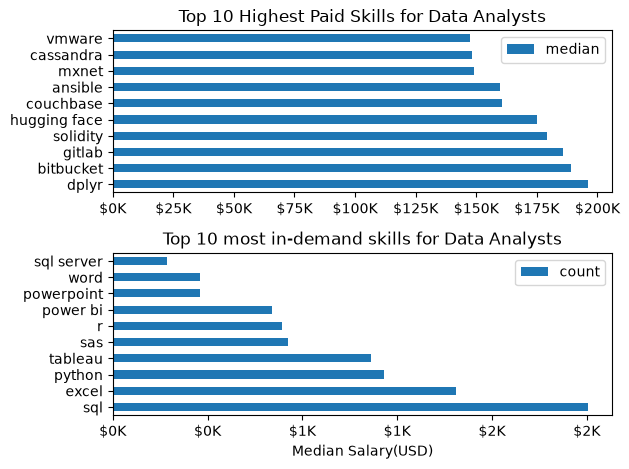

In [5]:
fig,ax =  plt.subplots(2,1) 
df_DA_top_pay[::-1].plot(kind='barh',y='median',ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'${int(x/1000)}K'))

df_DA_skills.plot(kind='barh',y='count',ax =ax[1])
ax[1]
ax[1].set_title('Top 10 most in-demand skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary(USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'${int(x/1000)}K'))

fig.tight_layout()


In [8]:
import seaborn as sns

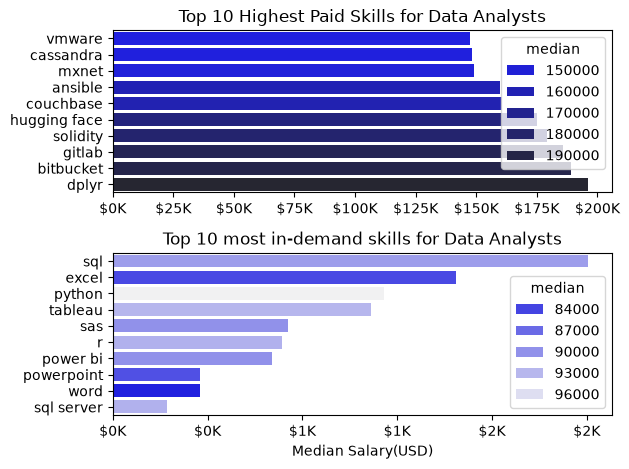

In [16]:
fig,ax =  plt.subplots(2,1) 
sns.barplot(data=df_DA_top_pay,x='median',y=df_DA_top_pay.index,ax=ax[0],hue='median',palette= 'dark:b_r')
#df_DA_top_pay[::-1].plot(kind='barh',y='median',ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'${int(x/1000)}K'))

#df_DA_skills.plot(kind='barh',y='count',ax =ax[1])
sns.barplot(data=df_DA_skills,x='count',y=df_DA_skills.index,ax=ax[1],hue='median',palette = 'light:b_r')

ax[1]
ax[1].set_title('Top 10 most in-demand skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary(USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'${int(x/1000)}K'))

fig.tight_layout()

Text(0.5, 9.444444444444427, 'Yearly Salary')

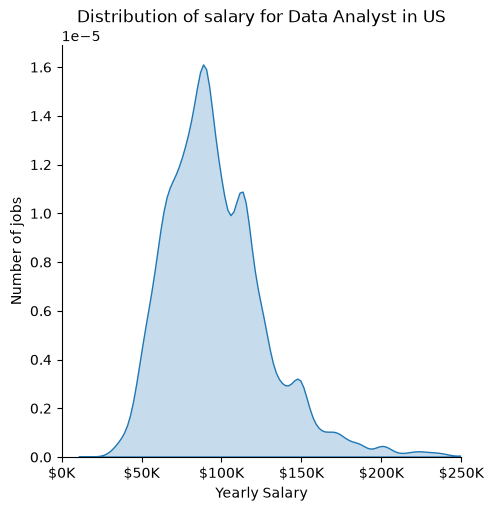

In [19]:
sns.displot(data = df_DA_US['salary_year_avg'],kind='kde',fill=True)
#df_DA_US ['salary_year_avg'].plot(kind='hist', bins=30,edgecolor = 'white') # bins:  số lượng cột
plt.xlim(0,250000) # khoảng cách của trục x

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _:f'${int(x/1000)}K')) # format kiểu định dạng của trục x 

plt.title ('Distribution of salary for Data Analyst in US')
plt.ylabel('Number of jobs')
plt.xlabel('Yearly Salary')

C:\Users\quang\AppData\Local\Temp\ipykernel_18736\2355723861.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list, label=job_titles, vert=False)


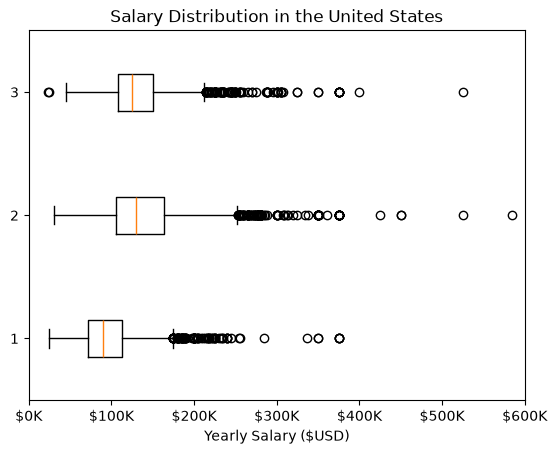

In [32]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

df_US = df[(df['job_title_short'].isin(job_titles))&(df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])
# list of salaries for each job title
job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, label=job_titles, vert=False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.show()

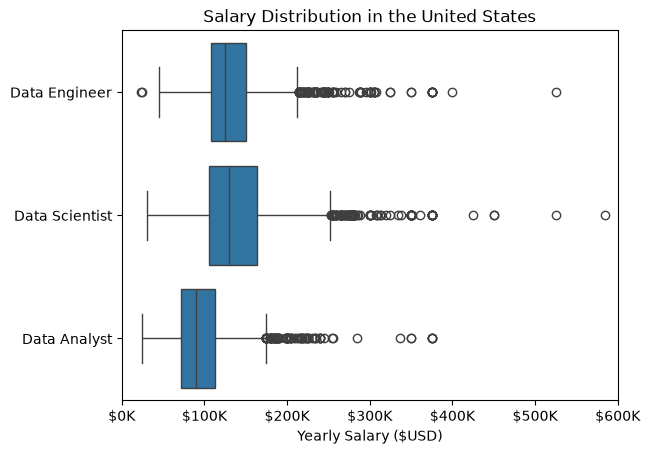

In [35]:
sns.boxplot(data=df_US, x='salary_year_avg',y ='job_title_short')
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.show()